# rider_kothe

Vortex-in-a-box: the disk stretches into a thin spiral filament by $t=4$,
then the flow reverses and it unwinds back to a disk at $t=8$. This is the
only case in the repo with genuine strain.

**On error norms.** $E_r$ is meaningful *only* at $t=0$ and $t=8$. The flow
returns the disk to its starting position at $t=8$, so the exact solution
there is the initial condition; at intermediate times the shape is a spiral
with no closed form. Boundedness, mass conservation and $|\nabla\psi|$ need no
reference solution, so those are reported throughout — and they are what the
animation annotates.


In [1]:
import glob, os, sys, logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.animation import FuncAnimation, FFMpegWriter
from mpi4py import MPI
from pysemtools.io.ppymech.neksuite import preadnek
from pysemtools.datatypes.msh import Mesh as msh_c
from pysemtools.datatypes.field import Field as field_c
from pysemtools.datatypes.coef import Coef

sys.path.insert(0, os.path.abspath(".."))   # examples/norms.py
import norms as nm

logging.disable(logging.INFO)
comm = MPI.COMM_WORLD
FPS = 10

# (tag, label, eps, gamma).  eps = xi * H/N with H = 1/64, N = 5.
RUNS = [("rider_kothe",      r"$\xi=1.5$, $\gamma=0.5$ (recommended)", 0.0046875, 0.5),
        ("rider_kothe_xi10", r"$\xi=1.0$, $\gamma=1.0$ (baseline)",    0.003125,  1.0)]

def frames(tag):
    return sorted(glob.glob(f"output_{tag}/field0.f?????"))

## Error at the return, and the reference-free diagnostics


In [2]:
msh = coef = None
print("E_r is quoted ONLY at t=8. The flow reverses at t=4 and returns the disk to")
print("its initial position, so t=8 has a known exact solution; at intermediate")
print("times the shape is a spiral with no closed form. Everything else below needs")
print("no reference solution and is therefore valid throughout the run.\n")
print(f"{'run':<20} {'E_r(t=8)':>10} {'E_v(t=8)':>11} {'worst viol':>11} {'l_avg/l0':>9}")
store = {}
for tag, label, eps, gam in RUNS:
    f = frames(tag)
    if not f:
        print(f"{tag:<20}  (no output)"); continue
    if msh is None:
        msh = msh_c(comm, data=preadnek(f[0], comm)); coef = Coef(msh, comm)
    pe  = nm.disk_phase(msh.x, msh.y, eps)
    per = nm.contour_length(msh, pe, 0.5)
    ts, viol, mass, lav, gmin, gmean, gmax = [], [], [], [], [], [], []
    p0 = field_c(comm, data=preadnek(f[0], comm)).fields["temp"][0]
    for ff in f:
        o = field_c(comm, data=preadnek(ff, comm))
        p, ps = o.fields["temp"][0], o.fields["scal"][0]
        g = np.sqrt(coef.dudxyz(ps, coef.drdx, coef.dsdx, coef.dtdx)**2
                  + coef.dudxyz(ps, coef.drdy, coef.dsdy, coef.dtdy)**2)
        b = p*(1.0 - p) > 1e-4
        ts.append(o.t); viol.append(max(p.max()-1.0, -p.min(), 0.0))
        mass.append(nm.E_v(p, p0, pe, coef, msh)); lav.append(nm.l_avg(p, coef, msh, per))
        gmin.append(g[b].min()); gmean.append(g[b].mean()); gmax.append(g[b].max())
    store[tag] = dict(t=np.array(ts), viol=np.array(viol), mass=np.array(mass),
                      lav=np.array(lav), gmin=np.array(gmin), gmean=np.array(gmean),
                      gmax=np.array(gmax), eps=eps, label=label, files=f, per=per)
    o = field_c(comm, data=preadnek(f[-1], comm)); p = o.fields["temp"][0]
    print(f"{tag:<20} {nm.E_r(p, pe, coef, msh):>10.5f} {mass[-1]:>11.2e} "
          f"{max(viol):>11.2e} {lav[-1]/lav[0]:>9.3f}")

E_r is quoted ONLY at t=8. The flow reverses at t=4 and returns the disk to
its initial position, so t=8 has a known exact solution; at intermediate
times the shape is a spiral with no closed form. Everything else below needs
no reference solution and is therefore valid throughout the run.

run                    E_r(t=8)    E_v(t=8)  worst viol  l_avg/l0


rider_kothe             0.27118   -2.29e-07    1.62e-30     1.606


rider_kothe_xi10        0.22353   -3.10e-06    3.98e-04     1.070


## The key result: $|\nabla\psi|$ drifts, then comes back

$D|\nabla\psi|/Dt = -|\nabla\psi|(\mathbf{n}\cdot\nabla\mathbf{u}\cdot\mathbf{n})$.
This flow's strain reverses with it, so the drift *integrates back to zero*.
Redistancing at $t=4$ would have reset $|\nabla\psi|$ to 1 at exactly the moment
the field is supposed to be strained — destroying the information that carries
it home. See `REDISTANCING.md`.


rider_kothe          |grad psi| band mean: t=0 1.0000  t=4   6.4066  t=8 1.0001   (min at t=4: 5.19e-03)
rider_kothe_xi10     |grad psi| band mean: t=0 1.0000  t=4   6.4481  t=8 1.0000   (min at t=4: 2.07e-02)


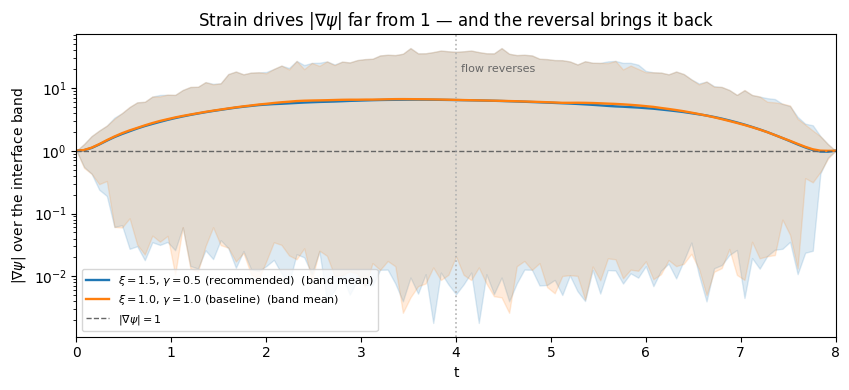

In [3]:
fig, ax = plt.subplots(figsize=(8.6, 4.0))
for (tag, label, eps, gam), c in zip(RUNS, ("C0", "C1")):
    d = store[tag]
    ax.fill_between(d["t"], d["gmin"], d["gmax"], color=c, alpha=0.15)
    ax.plot(d["t"], d["gmean"], color=c, lw=1.7, label=label + "  (band mean)")
ax.axhline(1.0, color="0.4", ls="--", lw=1.0, label=r"$|\nabla\psi|=1$")
ax.axvline(4.0, color="0.7", ls=":", lw=1.2)
ax.text(4.05, 18, "flow reverses", fontsize=8, color="0.4")
ax.set_yscale("log"); ax.set_xlabel("t"); ax.set_xlim(0, 8)
ax.set_ylabel(r"$|\nabla\psi|$ over the interface band")
ax.set_title(r"Strain drives $|\nabla\psi|$ far from 1 — and the reversal brings it back")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout(); os.makedirs("evidence", exist_ok=True)
fig.savefig("evidence/rider_grad_psi.png", dpi=140)
for tag, *_ in RUNS:
    d = store[tag]
    i4 = int(np.argmin(abs(d["t"] - 4.0)))
    print(f"{tag:<20} |grad psi| band mean: t=0 {d['gmean'][0]:.4f}  "
          f"t=4 {d['gmean'][i4]:8.4f}  t=8 {d['gmean'][-1]:.4f}   "
          f"(min at t=4: {d['gmin'][i4]:.2e})")

## The filament

Both settings, side by side. Annotations are the reference-free quantities.
The colour scale runs past $[0,1]$ so any boundedness violation shows as
saturation.


In [4]:
# Sequential map so the filament reads clearly, with explicit out-of-range
# colours so any boundedness violation is unmissable rather than washed out.
CM = plt.cm.magma.copy()
CM.set_under("#00d4ff")     # phi < 0
CM.set_over("#39ff14")      # phi > 1

iz = msh.z.shape[1] // 2
tri = mtri.Triangulation(msh.x[:, iz, :, :].ravel(), msh.y[:, iz, :, :].ravel())
vals = {tag: [field_c(comm, data=preadnek(f, comm)).fields["temp"][0][:, iz, :, :].ravel()
              for f in store[tag]["files"]] for tag, *_ in RUNS}
nf = min(len(v) for v in vals.values())

fig, axes = plt.subplots(1, 2, figsize=(10.4, 5.4))
meshes, notes = [], []
for ax, (tag, label, eps, gam) in zip(axes, RUNS):
    tp = ax.tripcolor(tri, vals[tag][0], shading="gouraud", cmap=CM, vmin=0.0, vmax=1.0)
    ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=10); ax.set_xlabel("x")
    notes.append(ax.text(0.03, 0.03, "", transform=ax.transAxes, fontsize=8,
                         family="monospace", va="bottom",
                         bbox=dict(fc="white", ec="0.8", alpha=0.9, pad=2.5)))
    meshes.append(tp)
axes[0].set_ylabel("y")
fig.colorbar(meshes[-1], ax=list(axes), fraction=0.03, pad=0.02, label=r"$\phi$")
sup = fig.suptitle("")

def frame(i):
    t = store[RUNS[0][0]]["t"][i]
    for k, (tag, label, eps, gam) in enumerate(RUNS):
        d = store[tag]; meshes[k].set_array(vals[tag][i])
        notes[k].set_text(f"$\\phi\\in$[{vals[tag][i].min():+.4f}, {vals[tag][i].max():+.4f}]\n"
                          f"$E_v$ = {d['mass'][i]:+.1e}\n"
                          f"$|\\nabla\\psi|$ mean {d['gmean'][i]:6.2f}")
    phase = "stretching" if t <= 4 else "unwinding"
    sup.set_text(f"Rider-Kothe, t = {t:4.2f} of 8   ({phase})   "
                 f"no redistancing, no SVV\n"
                 f"$E_r$ is undefined except at $t=0$ and $t=8$; boundedness and "
                 f"mass are not.  cyan $\\phi<0$, green $\\phi>1$")
    return meshes + notes + [sup]

out = "evidence/rider_kothe_methods.mp4"
FuncAnimation(fig, frame, frames=nf, blit=False).save(
    out, writer=FFMpegWriter(fps=FPS, bitrate=3000))
plt.close(fig)
print("wrote", out, f"({nf} frames)")

wrote evidence/rider_kothe_methods.mp4 (101 frames)


## The trade strain introduces: shape against boundedness

At $H=1/64$ the filament thins below what the interface can represent — $\phi$
peaks at only ~0.34 at maximum stretch instead of 1. A **smaller**
$\varepsilon$ (lower $\xi$) represents a thin filament better, so the shape
survives the return better. Boundedness moves the *other* way.

Neither `advecting_slab_1d` nor `zalesak_disk` can show this: both are
isometries, so nothing thins and larger $\xi$ simply wins there. This is the
one place the trade is visible.


   xi   gam       E_r  worst viol  phi max@t4
  1.0   1.0   0.22353    3.98e-04      0.3441
  1.5   0.5   0.27118    1.62e-30      0.3313
  1.5   1.0   0.30114    3.40e-69      0.2720
  1.5   2.0   0.31183    0.00e+00      0.2200
  2.0   1.0   0.34590    0.00e+00      0.2268

   mesh        eps       E_r  worst viol  phi max@t4
  1/64     0.003125   0.22353    3.98e-04      0.3441
  1/96     0.002083   0.15468    5.38e-04      0.4330
  1/128    0.001563   0.11570    6.80e-05      0.5055


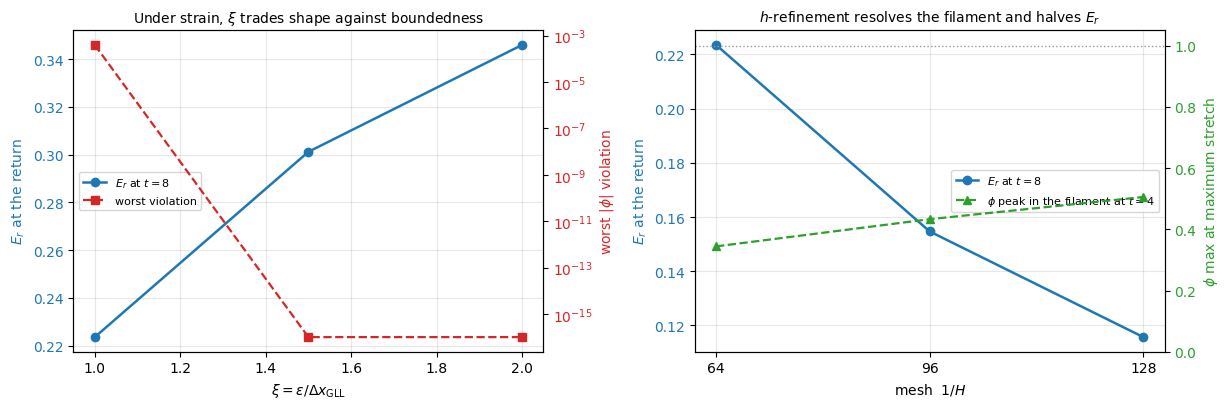

In [5]:
CROSS = [("rider_kothe_xi10", 1.0, 1.0, 0.003125),
         ("rider_kothe",      1.5, 0.5, 0.0046875),
         ("rider_x15_g10",    1.5, 1.0, 0.0046875),
         ("rider_x15_g20",    1.5, 2.0, 0.0046875),
         ("rider_x20_g10",    2.0, 1.0, 0.00625)]
HSER  = [("rider_kothe_xi10", 64,  0.003125),
         ("rider_h96",        96,  0.0020833333),
         ("rider_h128",       128, 0.0015625)]

def summarise(tag, eps):
    f = sorted(glob.glob(f"output_{tag}/field0.f?????"))
    m = msh_c(comm, data=preadnek(f[0], comm)); cf = Coef(m, comm)
    pe = nm.disk_phase(m.x, m.y, eps)
    worst, pmax4 = 0.0, np.nan
    for ff in f:
        o = field_c(comm, data=preadnek(ff, comm)); p = o.fields["temp"][0]
        worst = max(worst, max(p.max()-1.0, -p.min(), 0.0))
        if abs(o.t - 4.0) < 0.03: pmax4 = p.max()
    o = field_c(comm, data=preadnek(f[-1], comm))
    return nm.E_r(o.fields["temp"][0], pe, cf, m), worst, pmax4

xi_pts = [(xi, g) + summarise(t, e) for t, xi, g, e in CROSS]
h_pts  = [(h, e) + summarise(t, e) for t, h, e in HSER]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.2))

# left: the xi trade-off at gamma = 1
g1 = [p for p in xi_pts if p[1] == 1.0]
xs = [p[0] for p in g1]
a1.plot(xs, [p[2] for p in g1], "o-", color="C0", lw=1.8, label=r"$E_r$ at $t=8$")
a1.set_xlabel(r"$\xi = \varepsilon/\Delta x_{\rm GLL}$")
a1.set_ylabel(r"$E_r$ at the return", color="C0"); a1.tick_params(axis="y", labelcolor="C0")
b1 = a1.twinx()
b1.semilogy(xs, [max(p[3], 1e-16) for p in g1], "s--", color="C3", lw=1.6,
            label="worst violation")
b1.set_ylabel(r"worst $|\phi|$ violation", color="C3"); b1.tick_params(axis="y", labelcolor="C3")
a1.set_title(r"Under strain, $\xi$ trades shape against boundedness", fontsize=10)
a1.grid(alpha=0.3)
h, l = a1.get_legend_handles_labels(); h2, l2 = b1.get_legend_handles_labels()
a1.legend(h+h2, l+l2, fontsize=8, loc="center left")

# right: h-refinement fixes the filament
hs = [p[0] for p in h_pts]
a2.plot(hs, [p[2] for p in h_pts], "o-", color="C0", lw=1.8, label=r"$E_r$ at $t=8$")
a2.set_xlabel("mesh  $1/H$"); a2.set_xticks(hs)
a2.set_ylabel(r"$E_r$ at the return", color="C0"); a2.tick_params(axis="y", labelcolor="C0")
b2 = a2.twinx()
b2.plot(hs, [p[4] for p in h_pts], "^--", color="C2", lw=1.6,
        label=r"$\phi$ peak in the filament at $t=4$")
b2.axhline(1.0, color="0.6", ls=":", lw=1.0)
b2.set_ylabel(r"$\phi$ max at maximum stretch", color="C2")
b2.tick_params(axis="y", labelcolor="C2"); b2.set_ylim(0, 1.05)
a2.set_title(r"$h$-refinement resolves the filament and halves $E_r$", fontsize=10)
a2.grid(alpha=0.3)
h, l = a2.get_legend_handles_labels(); h2, l2 = b2.get_legend_handles_labels()
a2.legend(h+h2, l+l2, fontsize=8, loc="center right")
fig.tight_layout(); fig.savefig("evidence/rider_xi_and_h.png", dpi=140)

print(f"{'xi':>5}{'gam':>6}{'E_r':>10}{'worst viol':>12}{'phi max@t4':>12}")
for xi, g, er, w, pm in xi_pts:
    print(f"{xi:>5.1f}{g:>6.1f}{er:>10.5f}{w:>12.2e}{pm:>12.4f}")
print(f"\n{'mesh':>7}{'eps':>11}{'E_r':>10}{'worst viol':>12}{'phi max@t4':>12}")
for h_, e, er, w, pm in h_pts:
    print(f"  1/{h_:<4}{e:>11.6f}{er:>10.5f}{w:>12.2e}{pm:>12.4f}")

In [6]:
from IPython.display import Video
Video("evidence/rider_kothe_methods.mp4", embed=False, width=900)

## SVV on the ψ transport equation, no redistancing — $H=1/128$, $N=6$

Everything above has SVV off (this case's validated configuration). This
section is the first production test of `svv_psi` alone, on the one case
with real strain — SVV was worth 9–256× in $E_r$ on `zalesak_disk`
(`CDI_METHOD.md` §5), but that's an isometry; nothing has stretched there.

Three runs, otherwise identical ($\xi=1.0$, $\gamma=1.0$, `psi_init="exact"`,
redistancing off — matching `rider_h128.case`'s baseline, but at $N=6$
instead of $5$): `svv_psi.c0 = 1.0` (Saini's own §4.3 Zalesak value),
`c0 = 0.1` (their actual §4.5 Rider-Kothe value), and an SVV-off control at
this same $H,N$ (no shipped case runs $N=6$, so without this control there's
no baseline at this resolution to compare the two SVV runs against). All
three use $N_{svv}=N/2$.


In [7]:
# H=1/128, N=6, xi=1.0, gamma=1.0, psi_init="exact", no redistancing throughout --
# only svv_psi.c0 varies.
SVV_EPS = 0.0013020833
SVV_RUNS = [("rk_h128_n6_c10", r"$c_0=1.0$ (Zalesak §4.3)", 1.0),
            ("rk_h128_n6_c01", r"$c_0=0.1$ (Saini §4.5)",   0.1),
            ("rk_h128_n6_off", "SVV off",                    0.0)]

svv_msh = svv_coef = svv_pe = svv_per = None
svv_store = {}
print(f"{'run':<10} {'c0':>5} {'E_r(t=8)':>10} {'E_v(t=8)':>11} {'worst viol':>11} {'l_avg/l0':>9}")
for tag, label, c0 in SVV_RUNS:
    f = frames(tag)
    if not f:
        print(f"{tag:<10}  (no output yet)"); continue
    if svv_msh is None:
        svv_msh = msh_c(comm, data=preadnek(f[0], comm)); svv_coef = Coef(svv_msh, comm)
        svv_pe = nm.disk_phase(svv_msh.x, svv_msh.y, SVV_EPS)
        svv_per = nm.contour_length(svv_msh, svv_pe, 0.5)
    ts, viol, mass, lav, gmin, gmean, gmax = [], [], [], [], [], [], []
    psi_lo, psi_hi = np.inf, -np.inf
    p0 = field_c(comm, data=preadnek(f[0], comm)).fields["temp"][0]
    for ff in f:
        o = field_c(comm, data=preadnek(ff, comm))
        p, ps = o.fields["temp"][0], o.fields["scal"][0]
        psi_lo = min(psi_lo, ps.min()); psi_hi = max(psi_hi, ps.max())
        g = np.sqrt(svv_coef.dudxyz(ps, svv_coef.drdx, svv_coef.dsdx, svv_coef.dtdx)**2
                  + svv_coef.dudxyz(ps, svv_coef.drdy, svv_coef.dsdy, svv_coef.dtdy)**2)
        b = p*(1.0 - p) > 1e-4
        ts.append(o.t); viol.append(max(p.max()-1.0, -p.min(), 0.0))
        mass.append(nm.E_v(p, p0, svv_pe, svv_coef, svv_msh))
        lav.append(nm.l_avg(p, svv_coef, svv_msh, svv_per))
        gmin.append(g[b].min()); gmean.append(g[b].mean()); gmax.append(g[b].max())
    er8 = nm.E_r(p, svv_pe, svv_coef, svv_msh)  # p is now the last frame's phi (loop just ended)
    svv_store[tag] = dict(t=np.array(ts), viol=np.array(viol), mass=np.array(mass),
                           lav=np.array(lav), gmin=np.array(gmin), gmean=np.array(gmean),
                           gmax=np.array(gmax), label=label, c0=c0, files=f,
                           psi_lo=psi_lo, psi_hi=psi_hi, er8=er8)
    print(f"{tag:<10} {c0:>5.1f} {er8:>10.5f} "
          f"{mass[-1]:>11.2e} {max(viol):>11.2e} {lav[-1]/lav[0]:>9.3f}")

# True psi range over the whole run, all three -- informational only. It's very
# asymmetric (most of the box is far from the disk, so the negative tail is
# ~3.7x the positive one, which tops out at exactly the disk radius). Plotting
# cells below use a tighter, symmetric, physically-motivated display range
# instead of this one -- see PSI_RANGE there.
psi_vmin = min(d["psi_lo"] for d in svv_store.values())
psi_vmax = max(d["psi_hi"] for d in svv_store.values())
print(f"\ntrue psi range over the whole run: [{psi_vmin:.4f}, {psi_vmax:.4f}]")

run           c0   E_r(t=8)    E_v(t=8)  worst viol  l_avg/l0


rk_h128_n6_c10   1.0    0.09624    1.21e-07    6.42e-04     1.031


rk_h128_n6_c01   0.1    0.09526    3.48e-07    6.55e-04     1.038


rk_h128_n6_off   0.0    0.09416    9.84e-07    1.82e-03     1.033

true psi range over the whole run: [-0.5591, 0.1500]


### Snapshot at the return ($t=8$), $\phi$ and $\psi$ side by side


wrote evidence/rider_svv_snapshots.png


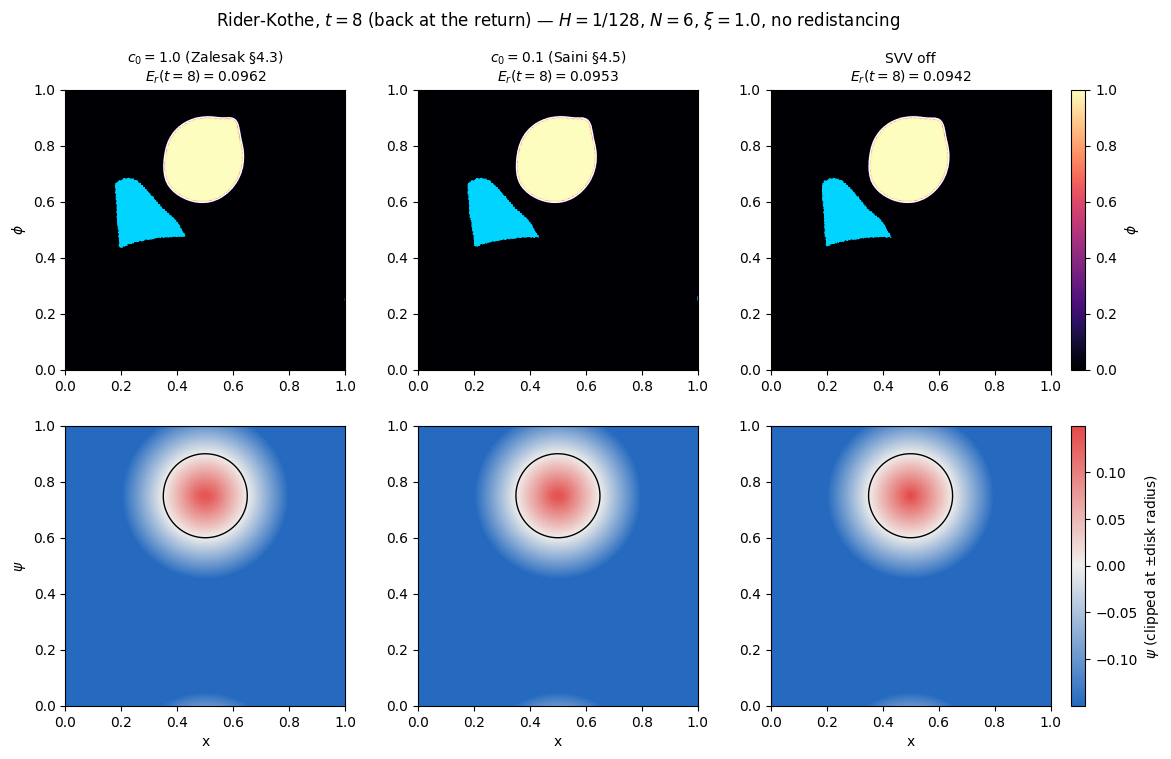

In [8]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

# phi: reverted to magma + cyan/green (matches this repo's existing convention,
# e.g. zalesak_disk). A tried single-hue sequential blue ramp (the dataviz
# skill's generic guidance for magnitude data) made the interface -- physically
# only ~2*epsilon=0.0026 wide -- visually disappear: magma's wide hue+lightness
# swing (black->purple->orange->yellow) is what makes a band that thin still
# read as a distinct ring; a monochromatic ramp doesn't have enough local
# contrast for it, regardless of how it's chosen. Amber/red alarm colors were
# also checked and rejected: amber collides with magma's own in-range orange
# (Delta E 5.6/5.1/9.7, all below target) since magma naturally passes through
# amber-ish hues -- cyan/green avoid magma's gamut entirely, which is why
# they were the right choice all along.
PHI_CM = plt.cm.magma.copy()
PHI_CM.set_under("#00d4ff"); PHI_CM.set_over("#39ff14")
# psi: diverging blue/gray/red from the repo's dataviz palette, validated with
# validate_palette.js -- Delta E 19.2/34.6/32.2, all clear of target.
PSI_CM = LinearSegmentedColormap.from_list("psi_diverging", ["#256abf", "#f0efec", "#e34948"])

# psi's *display* range is NOT its true data range (that's [-0.56, +0.15], very
# asymmetric -- most of the box is far from the disk). Stretching the colormap
# to cover that wastes almost all the contrast on the empty far field and
# leaves nothing for the interface. Use a symmetric range instead, tied to the
# disk radius (psi's own exact positive bound, always 0.15) -- far field simply
# saturates to solid colour, which is correct: it isn't interesting, and isn't
# noise either (the true range check found no outlier population to clip).
PSI_RANGE = 0.15  # = SLOT_R, examples/norms.py
psi_norm = TwoSlopeNorm(vmin=-PSI_RANGE, vcenter=0.0, vmax=PSI_RANGE)

iz2 = svv_msh.z.shape[1] // 2
svv_tri = mtri.Triangulation(svv_msh.x[:, iz2, :, :].ravel(), svv_msh.y[:, iz2, :, :].ravel())

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.0))
for col, (tag, label, c0) in enumerate(SVV_RUNS):
    if tag not in svv_store:
        for row in range(2): axes[row, col].axis("off")
        continue
    o = field_c(comm, data=preadnek(svv_store[tag]["files"][-1], comm))
    phi_v = o.fields["temp"][0][:, iz2, :, :].ravel()
    psi_v = o.fields["scal"][0][:, iz2, :, :].ravel()
    tp0 = axes[0, col].tripcolor(svv_tri, phi_v, shading="gouraud", cmap=PHI_CM, vmin=0.0, vmax=1.0)
    tp1 = axes[1, col].tripcolor(svv_tri, psi_v, shading="gouraud", cmap=PSI_CM, norm=psi_norm)
    # the interface itself: phi=0.5 and (as a cross-check) psi=0 should coincide
    axes[0, col].tricontour(svv_tri, phi_v, levels=[0.5], colors="w", linewidths=1.0)
    axes[1, col].tricontour(svv_tri, psi_v, levels=[0.0], colors="k", linewidths=1.0)
    for row in range(2):
        axes[row, col].set_aspect("equal"); axes[row, col].set_xlim(0, 1); axes[row, col].set_ylim(0, 1)
    axes[0, col].set_title(f"{label}\n" + r"$E_r(t{=}8) = $" + f"{svv_store[tag]['er8']:.4f}",
                            fontsize=10)
    axes[1, col].set_xlabel("x")
axes[0, 0].set_ylabel(r"$\phi$"); axes[1, 0].set_ylabel(r"$\psi$")
fig.colorbar(tp0, ax=list(axes[0, :]), fraction=0.025, pad=0.02, label=r"$\phi$")
fig.colorbar(tp1, ax=list(axes[1, :]), fraction=0.025, pad=0.02, label=r"$\psi$ (clipped at $\pm$disk radius)")
fig.suptitle(r"Rider-Kothe, $t=8$ (back at the return) — $H=1/128$, $N=6$, $\xi=1.0$, no redistancing")
fig.savefig("evidence/rider_svv_snapshots.png", dpi=140)
print("wrote evidence/rider_svv_snapshots.png")

### Animation over the full run, $\phi$ and $\psi$ for all three


In [9]:
active_runs = [(tag, label, c0) for tag, label, c0 in SVV_RUNS if tag in svv_store]
nf_svv = min(len(svv_store[tag]["files"]) for tag, *_ in active_runs)

# Frames are loaded on demand, not preloaded -- three runs x ~200 frames x two
# fields at N=6 is tens of GB if held in memory at once (this is what OOM'd the
# first attempt at this cell).
def load_frame(tag, i):
    o = field_c(comm, data=preadnek(svv_store[tag]["files"][i], comm))
    return (o.fields["temp"][0][:, iz2, :, :].ravel(),
            o.fields["scal"][0][:, iz2, :, :].ravel())

fig, axes = plt.subplots(2, len(active_runs), figsize=(4.4 * len(active_runs), 8.0), squeeze=False)
meshes_phi, meshes_psi, notes = [], [], []
contours_phi, contours_psi = [], []
for col, (tag, label, c0) in enumerate(active_runs):
    phi0, psi0 = load_frame(tag, 0)
    tp = axes[0, col].tripcolor(svv_tri, phi0, shading="gouraud", cmap=PHI_CM, vmin=0.0, vmax=1.0)
    tq = axes[1, col].tripcolor(svv_tri, psi0, shading="gouraud", cmap=PSI_CM, norm=psi_norm)
    contours_phi.append(axes[0, col].tricontour(svv_tri, phi0, levels=[0.5], colors="w", linewidths=1.0))
    contours_psi.append(axes[1, col].tricontour(svv_tri, psi0, levels=[0.0], colors="k", linewidths=1.0))
    for row in range(2):
        axes[row, col].set_aspect("equal"); axes[row, col].set_xlim(0, 1); axes[row, col].set_ylim(0, 1)
    axes[0, col].set_title(label, fontsize=10); axes[1, col].set_xlabel("x")
    notes.append(axes[0, col].text(0.03, 0.03, "", transform=axes[0, col].transAxes, fontsize=7,
                    family="monospace", va="bottom", color="w",
                    bbox=dict(fc="black", ec="0.5", alpha=0.6, pad=2.0)))
    meshes_phi.append(tp); meshes_psi.append(tq)
axes[0, 0].set_ylabel(r"$\phi$"); axes[1, 0].set_ylabel(r"$\psi$")
fig.colorbar(meshes_phi[-1], ax=list(axes[0, :]), fraction=0.025, pad=0.02, label=r"$\phi$")
fig.colorbar(meshes_psi[-1], ax=list(axes[1, :]), fraction=0.025, pad=0.02, label=r"$\psi$ (clipped at $\pm$disk radius)")
sup = fig.suptitle("")

def svv_frame(i):
    t = svv_store[active_runs[0][0]]["t"][i]
    at_return = (i == nf_svv - 1)  # E_r has no closed-form reference before t=8
    for k, (tag, label, c0) in enumerate(active_runs):
        d = svv_store[tag]
        phi_v, psi_v = load_frame(tag, i)
        meshes_phi[k].set_array(phi_v); meshes_psi[k].set_array(psi_v)
        # contour lines have no set_data equivalent -- redraw each frame
        contours_phi[k].remove(); contours_psi[k].remove()
        contours_phi[k] = axes[0, k].tricontour(svv_tri, phi_v, levels=[0.5], colors="w", linewidths=1.0)
        contours_psi[k] = axes[1, k].tricontour(svv_tri, psi_v, levels=[0.0], colors="k", linewidths=1.0)
        er_txt = f"{d['er8']:.4f}" if at_return else "— (only defined at $t{=}8$)"
        notes[k].set_text(f"$\\phi\\in$[{phi_v.min():+.3f}, {phi_v.max():+.3f}]\n"
                          f"$|\\nabla\\psi|$ mean {d['gmean'][i]:6.2f}\n"
                          f"$E_r$ = {er_txt}")
    phase = "stretching" if t <= 4 else "unwinding"
    sup.set_text(f"Rider-Kothe, t = {t:4.2f} of 8   ({phase})   $H=1/128$, $N=6$, no redistancing\n"
                 f"cyan $\\phi<0$, green $\\phi>1$   —   contour: the interface ($\\phi=0.5$ / $\\psi=0$)")
    return meshes_phi + meshes_psi + notes + [sup]

out = "evidence/rider_svv_methods.mp4"
FuncAnimation(fig, svv_frame, frames=nf_svv, blit=False).save(
    out, writer=FFMpegWriter(fps=FPS, bitrate=3000))
plt.close(fig)
print("wrote", out, f"({nf_svv} frames, {len(active_runs)} runs)")

wrote evidence/rider_svv_methods.mp4 (202 frames, 3 runs)
